<a href="https://colab.research.google.com/github/alifnursetyovimanto/RFM-Customer-Segmentation/blob/main/Customer_Churn_Prediction_Telco_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Churn Prediction — Telco Dataset

## Latar belakang masalah
Perusahaan telekomunikasi kehilangan pelanggan setiap bulan (churn).
Mengakuisisi pelanggan baru 5–7x lebih mahal dibanding mempertahankan
pelanggan lama. Project ini bertujuan memprediksi pelanggan mana yang
berisiko churn agar tim bisnis bisa melakukan intervensi lebih awal.

## Pertanyaan yang ingin dijawab
1. Faktor apa yang paling kuat memprediksi churn?
2. Model apa yang paling efektif untuk kasus ini?
3. Apa rekomendasi bisnis berdasarkan temuan?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report,
    confusion_matrix, roc_auc_score, roc_curve)
from imblearn.over_sampling import SMOTE
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn


In [2]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

df = pd.read_csv('/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.shape)
df.head(5)

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print("Shape:", df.shape)
print("\nInfo:")
df.info()

Shape: (7043, 21)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling 

In [4]:
print("\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])


Missing values:
Series([], dtype: int64)


In [5]:
print("\nChurn distribution:")
print(df['Churn'].value_counts(normalize=True).round(3) * 100)


Churn distribution:
Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64


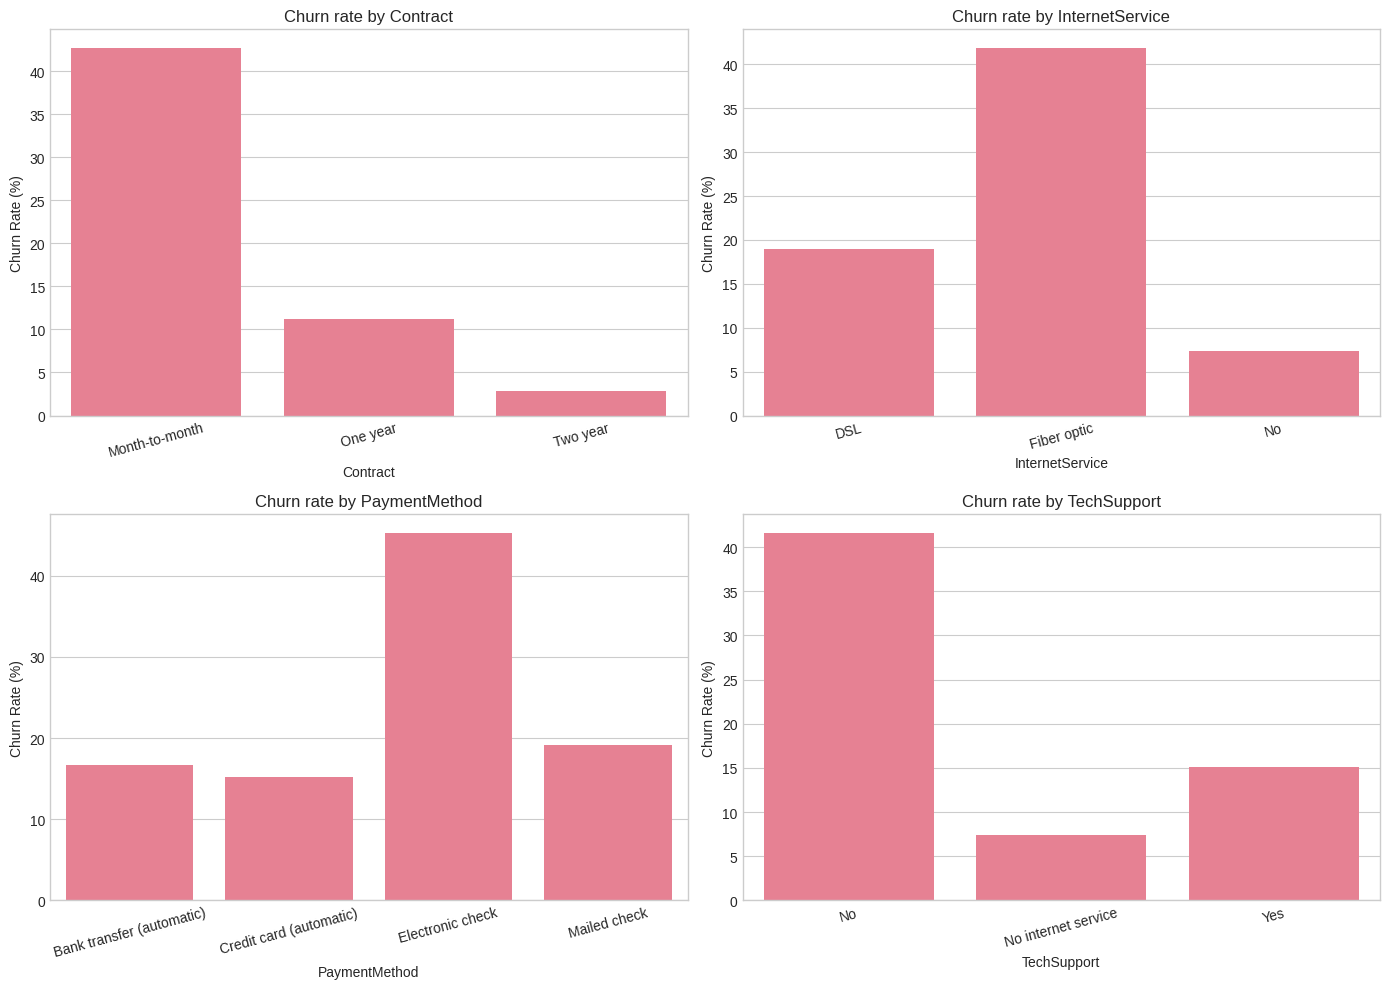

In [6]:
cat_features = ['Contract', 'InternetService',
                'PaymentMethod', 'TechSupport']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    churn_rate = (df.groupby(col)['Churn']
                  .apply(lambda x: (x == 'Yes').mean() * 100)
                  .reset_index())
    churn_rate.columns = [col, 'Churn Rate (%)']

    sns.barplot(data=churn_rate, x=col, y='Churn Rate (%)', ax=axes[i])
    axes[i].set_title(f'Churn rate by {col}')
    axes[i].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('churn_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

## Temuan EDA

**Pola churn yang ditemukan:**
- Pelanggan dengan kontrak month-to-month memiliki churn rate 43%
  vs only 3% untuk two-year contract
- Pelanggan dengan Fiber Optic internet lebih banyak churn (~42%) dibanding DSL (~19%) — kemungkinan karena harga lebih tinggi
- Tidak punya TechSupport → churn rate 2x lebih tinggi

**Hipotesis awal:**
Churn banyak terjadi pada pelanggan baru (tenure pendek) yang belum
terikat kontrak panjang dan tidak merasakan value dari layanan tambahan.

**Keputusan preprocessing:**
Fokus fitur pada: Contract, tenure, MonthlyCharges, TechSupport,
OnlineSecurity — karena paling informatif secara visual.

In [7]:
# Fix TotalCharges yang masuk sebagai string
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Drop kolom tidak relevan
df.drop('customerID', axis=1, inplace=True)

# Encode target variable
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

# Encode semua kolom kategori dengan one-hot encoding
df_encoded = pd.get_dummies(df, drop_first=True)

print(f"Shape setelah encoding: {df_encoded.shape}")
df_encoded.head()

Shape setelah encoding: (7043, 31)


/tmp/ipykernel_3108/91632292.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [8]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# SMOTE: oversample kelas minoritas (churn) di training data
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("Sebelum SMOTE:", y_train.value_counts().to_dict())
print("Setelah SMOTE:", pd.Series(y_train_bal).value_counts().to_dict())

Sebelum SMOTE: {0: 4139, 1: 1495}
Setelah SMOTE: {0: 4139, 1: 4139}


In [9]:
# Model 1: Logistic Regression (baseline — simpel, interpretable)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled  = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train_bal)

# Model 2: Random Forest (lebih powerful, tapi lebih black box)
rf = RandomForestClassifier(n_estimators=100, random_state=42,
                             class_weight='balanced')
rf.fit(X_train_bal, y_train_bal)

print("Models trained.")

Models trained.


In [10]:
def evaluate_model(model, X_test, y_test, model_name, scaled=False):
    X = X_test_scaled if scaled else X_test
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]

    print(f"\n=== {model_name} ===")
    print(classification_report(y_test, y_pred,
          target_names=['Tidak churn', 'Churn']))
    print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.3f}")
    return y_pred, y_prob

lr_pred, lr_prob = evaluate_model(lr, X_test, y_test,
                                   "Logistic Regression", scaled=True)
rf_pred, rf_prob = evaluate_model(rf, X_test, y_test, "Random Forest")


=== Logistic Regression ===
              precision    recall  f1-score   support

 Tidak churn       0.86      0.81      0.83      1035
       Churn       0.54      0.63      0.58       374

    accuracy                           0.76      1409
   macro avg       0.70      0.72      0.71      1409
weighted avg       0.77      0.76      0.77      1409

ROC-AUC: 0.812

=== Random Forest ===
              precision    recall  f1-score   support

 Tidak churn       0.85      0.84      0.84      1035
       Churn       0.57      0.59      0.58       374

    accuracy                           0.77      1409
   macro avg       0.71      0.71      0.71      1409
weighted avg       0.78      0.77      0.77      1409

ROC-AUC: 0.821


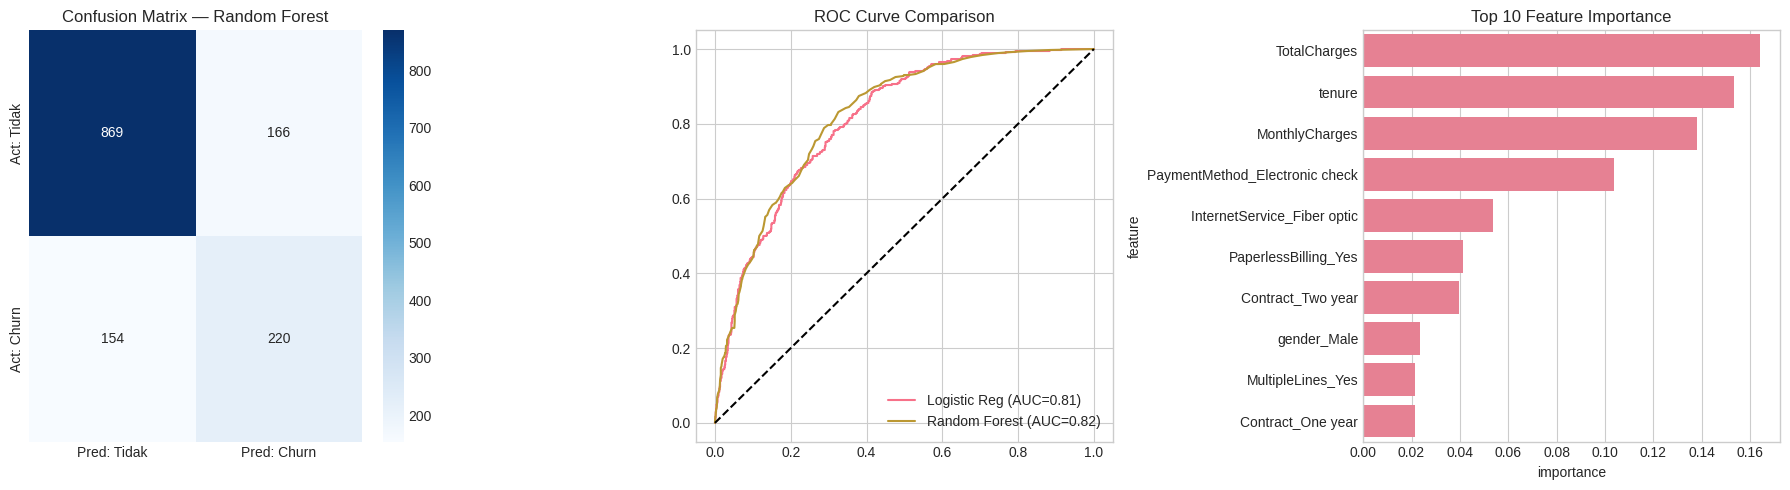

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix — Random Forest
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
           xticklabels=['Pred: Tidak', 'Pred: Churn'],
           yticklabels=['Act: Tidak', 'Act: Churn'])
axes[0].set_title('Confusion Matrix — Random Forest')

# ROC Curve — kedua model
for prob, name in [(lr_prob, 'Logistic Reg'), (rf_prob, 'Random Forest')]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={auc:.2f})')
axes[1].plot([0,1], [0,1], 'k--')
axes[1].set_title('ROC Curve Comparison')
axes[1].legend()

# Feature Importance — Random Forest
feat_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False).head(10)

sns.barplot(data=feat_imp, y='feature', x='importance', ax=axes[2])
axes[2].set_title('Top 10 Feature Importance')

plt.tight_layout()
plt.savefig('model_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# Coba threshold yang lebih rendah dari default 0.5
# untuk meningkatkan recall lebih jauh
thresholds = [0.3, 0.4, 0.5]
for t in thresholds:
    y_pred_t = (lr_prob >= t).astype(int)
    print(f"Threshold {t}: ", classification_report(y_test, y_pred_t, output_dict=True)['1'])

Threshold 0.3:  {'precision': 0.45648854961832064, 'recall': 0.7994652406417112, 'f1-score': 0.5811467444120505, 'support': 374.0}
Threshold 0.4:  {'precision': 0.49444444444444446, 'recall': 0.713903743315508, 'f1-score': 0.5842450765864332, 'support': 374.0}
Threshold 0.5:  {'precision': 0.542528735632184, 'recall': 0.6310160427807486, 'f1-score': 0.5834363411619283, 'support': 374.0}


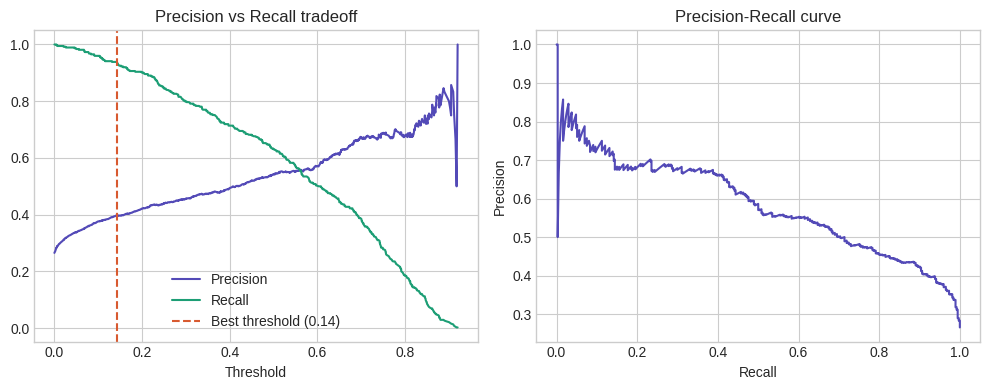

Threshold optimal (F2): 0.14
Precision: 0.40, Recall: 0.94


In [20]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precisions, recalls, thresholds = precision_recall_curve(y_test, lr_prob)

# Hitung F-beta score — beta > 1 berarti recall lebih diprioritaskan
# Beta=2 artinya recall 2x lebih penting dari precision
beta = 2
fbeta = ((1 + beta**2) * precisions * recalls) / (beta**2 * precisions + recalls + 1e-9)
best_idx = fbeta.argmax()
best_threshold = thresholds[best_idx]

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(thresholds, precisions[:-1], label='Precision', color='#534AB7')
plt.plot(thresholds, recalls[:-1], label='Recall', color='#1D9E75')
plt.axvline(best_threshold, color='#D85A30', linestyle='--', label=f'Best threshold ({best_threshold:.2f})')
plt.xlabel('Threshold')
plt.legend()
plt.title('Precision vs Recall tradeoff')

plt.subplot(1, 2, 2)
plt.plot(recalls, precisions, color='#534AB7')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curve')
plt.tight_layout()
plt.savefig('pr_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Threshold optimal (F2): {best_threshold:.2f}")
print(f"Precision: {precisions[best_idx]:.2f}, Recall: {recalls[best_idx]:.2f}")

Confusion matrix threshold 0.14:
True Negative  (aman, prediksi aman)  : 504
False Positive (aman, prediksi churn) : 531
False Negative (churn, prediksi aman) : 23
True Positive  (churn, prediksi churn): 351

Dari 1035 pelanggan aman, 531 dapat promo tidak perlu
(51% false positive rate)


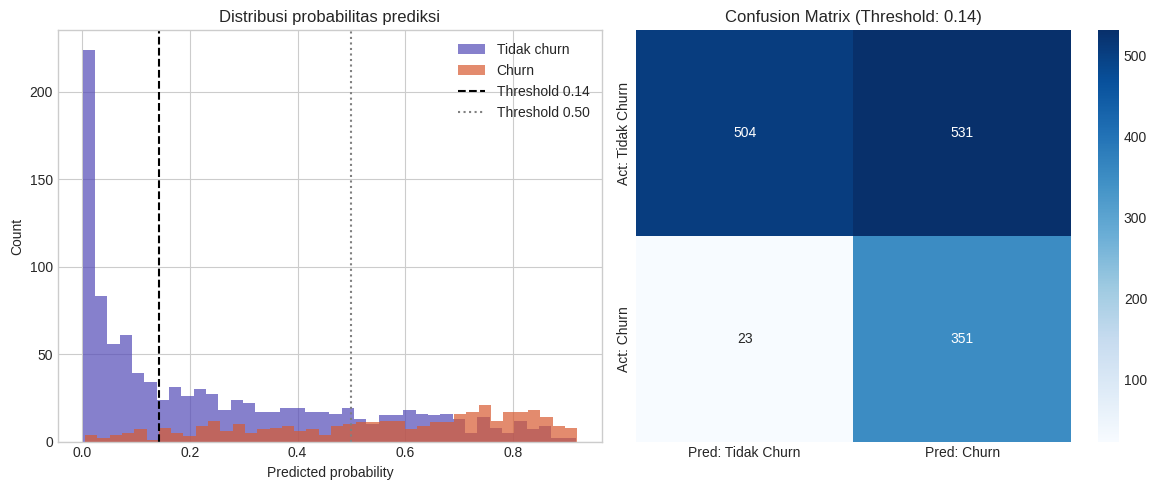

In [24]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(lr_prob[y_test == 0], bins=40, alpha=0.7,
         color='#534AB7', label='Tidak churn')
plt.hist(lr_prob[y_test == 1], bins=40, alpha=0.7,
         color='#D85A30', label='Churn')
plt.axvline(best_threshold, color='black', linestyle='--', label=f'Threshold {best_threshold:.2f}')
plt.axvline(0.50, color='gray', linestyle=':', label='Threshold 0.50')
plt.xlabel('Predicted probability')
plt.ylabel('Count')
plt.legend()
plt.title('Distribusi probabilitas prediksi')

plt.subplot(1, 2, 2)
# Display confusion matrix as a heatmap
from sklearn.metrics import confusion_matrix
y_pred_at_best_threshold = (lr_prob >= best_threshold).astype(int)
cm_at_best_threshold = confusion_matrix(y_test, y_pred_at_best_threshold)
print("Confusion matrix threshold 0.14:")
print(f"True Negative  (aman, prediksi aman)  : {cm_at_best_threshold[0,0]}")
print(f"False Positive (aman, prediksi churn) : {cm_at_best_threshold[0,1]}")
print(f"False Negative (churn, prediksi aman) : {cm_at_best_threshold[1,0]}")
print(f"True Positive  (churn, prediksi churn): {cm_at_best_threshold[1,1]}")
print(f"\nDari {cm_at_best_threshold[0,0]+cm_at_best_threshold[0,1]} pelanggan aman, {cm_at_best_threshold[0,1]} dapat promo tidak perlu")
print(f"({cm_at_best_threshold[0,1]/(cm_at_best_threshold[0,0]+cm_at_best_threshold[0,1])*100:.0f}% false positive rate)")
sns.heatmap(cm_at_best_threshold, annot=True, fmt='d', cmap='Blues',
           xticklabels=['Pred: Tidak Churn', 'Pred: Churn'],
           yticklabels=['Act: Tidak Churn', 'Act: Churn'])
plt.title(f'Confusion Matrix (Threshold: {best_threshold:.2f})')

plt.tight_layout()
plt.savefig('prob_dist_cm_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

## Kesimpulan & rekomendasi bisnis

### Apa yang saya kerjakan
Dataset Telco Customer Churn (7.043 pelanggan) digunakan untuk membangun
model prediksi churn menggunakan Logistic Regression dan Random Forest.
Seluruh proses mulai dari EDA, preprocessing, modelling, hingga threshold
analysis dikerjakan secara mandiri.

### Hasil model
| Metrik | Logistic Regression | Random Forest |
|---|---|---|
| Accuracy | 76% | 77% |
| Recall (churn) | 63% → 94%* | 59% |
| Precision (churn) | 54% → 40%* | 57% |
| ROC-AUC | 0.812 | 0.821 |

*setelah threshold adjustment ke 0.14

### Model yang dipilih: Logistic Regression + threshold 0.14
Alasan pemilihan:
1. **Recall lebih tinggi** — 94% churn berhasil dideteksi vs 59% Random Forest
2. **Interpretable** — koefisien bisa dijelaskan ke stakeholder non-teknis
3. **False negative hanya 23 orang** dari 374 — hampir semua calon churn tertangkap

### Temuan bisnis utama
1. Pelanggan dengan kontrak **month-to-month** memiliki churn rate 43%
   — 14x lebih tinggi dari kontrak two-year (3%)
2. Pelanggan **tanpa TechSupport dan OnlineSecurity** churn 2x lebih banyak
3. **Tenure < 12 bulan** adalah periode paling kritis — churn paling banyak
   terjadi di tahun pertama

### Rekomendasi aksi untuk tim bisnis
Berdasarkan 351 pelanggan yang berhasil dideteksi di test set:

**Jika biaya intervensi rendah (email, push notification):**
→ Gunakan threshold 0.14 — flag semua 887 pelanggan berisiko (351 TP + 531 FP)
→ Kirim retention offer otomatis, cost per orang sangat murah

**Jika biaya intervensi tinggi (diskon besar, sales call):**
→ Naikkan threshold ke 0.30–0.35 — prioritaskan kasus dengan probabilitas lebih tinggi
→ Lebih sedikit orang diintervensi tapi conversion rate retensi lebih tinggi

**Program yang disarankan:**
- Bulan 1–6: welcome program + trial layanan premium gratis
- Pelanggan month-to-month: insentif upgrade ke kontrak tahunan
- Cross-sell TechSupport/OnlineSecurity saat onboarding

### Keterbatasan
- Dataset statis (snapshot) — model perlu di-retrain secara berkala dengan data baru
- Belum ada validasi A/B test untuk mengukur efektivitas intervensi nyata
- Probability calibration belum dilakukan — threshold 0.14 yang rendah
  mengindikasikan model perlu dikalibrasi agar probabilitas lebih reliable

### Kalau ada waktu lebih, saya akan mencoba
- XGBoost + hyperparameter tuning untuk meningkatkan AUC
- SHAP values untuk explainability yang lebih dalam
- Probability calibration dengan Platt Scaling atau Isotonic Regression

In [25]:
import joblib

# Simpan model, scaler, dan threshold
joblib.dump(lr, 'model_churn_lr.pkl')
joblib.dump(scaler, 'scaler_churn.pkl')

# Simpan threshold optimal
import json
with open('model_config.json', 'w') as f:
    json.dump({
        'threshold': round(float(best_threshold), 2),
        'model': 'LogisticRegression',
        'features': list(X.columns),
        'roc_auc': 0.812,
        'recall_at_threshold': 0.94,
        'precision_at_threshold': 0.40
    }, f, indent=2)

print("Model tersimpan:")
print("- model_churn_lr.pkl")
print("- scaler_churn.pkl")
print("- model_config.json")

Model tersimpan:
- model_churn_lr.pkl
- scaler_churn.pkl
- model_config.json


## Refleksi proses

**Yang paling menantang:**
Class imbalance dan pemilihan threshold — saya belajar bahwa threshold
bukan parameter teknis, tapi keputusan bisnis yang harus melibatkan
stakeholder.

**Yang saya pelajari:**
Accuracy bukan metrik yang tepat untuk imbalanced dataset. Dalam kasus
ini, model dengan accuracy 76% justru lebih berguna dari model dengan
accuracy 90% yang gagal mendeteksi churn.

**Yang akan saya eksplorasi selanjutnya:**
Mengapa probability model menumpuk di range 0.0–0.2? Ini indikasi
model perlu probability calibration — topik yang ingin saya pelajari
di project berikutnya.